<a href="https://colab.research.google.com/github/krishnasaijoga/ScalerCaseStudies/blob/main/AmazonProdRecommSysCS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A good recommendation system must be:
1. Relevant: closeness of recommended product matching the user's interests
2. Diverse: recommendations shouldn't all look the same
3. Has Coverage: how much of the catalog is actually getting recommended
4. Works for: new users, returning users, and new products

Precision@K: Out of top K recommendations, how many are relevant

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
import requests
import io
from imblearn.over_sampling import SMOTE
from typing import List, Dict, Tuple, Optional, Set
from sklearn.decomposition import TruncatedSVD

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

### Data Understanding

In [3]:
def load_data(path: str) -> pd.DataFrame:
  !gdown --fuzzy --output amazon_dataset.csv "$DATA_PATH" # $DATA_PATH means to parse url before retrieval
  data=pd.read_csv("/content/amazon_dataset.csv")
  return data

In [4]:
#cleaning column names
def column_name_cleaning(df):
  df.columns=df.columns.str.strip()
  df.columns=df.columns.str.lower()
  df.columns=df.columns.str.replace(' ','_')
  return df

In [5]:
def build_interaction_df(data: pd.DataFrame) -> pd.DataFrame:
  data['user_id']=data['user_id'].astype('str')
  data['user_id']=data['user_id'].str.split(',')
  interaction_df=data.explode('user_id')
  interaction_df['user_id']=interaction_df['user_id'].str.strip()
  return interaction_df

In [6]:
def compute_structural_metrics(interaction_df: pd.DataFrame) -> Dict:
  total_rows=len(interaction_df)
  unique_users=interaction_df['user_id'].nunique()
  unique_products=interaction_df['product_id'].nunique()
  avg_interactions_per_user=round(total_rows/unique_users,2)
  avg_interactions_per_prod=round(total_rows/unique_products,2)
  sparsity=1-(total_rows/(unique_users*unique_products))
  metrics={
      "total_interactions":total_rows,
      "unique_users":unique_users,
      "unique_products":unique_products,
      "average_interactions_per_user":avg_interactions_per_user,
      "average_interactions_per_product":avg_interactions_per_prod,
      "sparsity_percentage":round(sparsity*100,2)
  }
  return metrics

In [7]:
def run_phase1(path: str):
  data=load_data(path)
  data=column_name_cleaning(data)
  interaction_df=build_interaction_df(data)
  metrics=compute_structural_metrics(interaction_df)
  print("\n-----Structural Audit Results-----")
  for k,v in metrics.items():
    print(f"{k}: {v}")
  return data,interaction_df,metrics

In [8]:
DATA_PATH='https://drive.google.com/file/d/145Nm57oIREHYp1viIYrl7zkQMtSTRhvA/view?usp=sharing'
data, interaction_df, metrics=run_phase1(DATA_PATH)

Downloading...
From: https://drive.google.com/uc?id=145Nm57oIREHYp1viIYrl7zkQMtSTRhvA
To: /content/amazon_dataset.csv
100% 4.74M/4.74M [00:00<00:00, 38.1MB/s]

-----Structural Audit Results-----
total_interactions: 11503
unique_users: 9050
unique_products: 1351
average_interactions_per_user: 1.27
average_interactions_per_product: 8.51
sparsity_percentage: 99.91


1. avg_interactions_per_product is nearly 1 for every user, so user-user CF will be unstable with almost no overlap between users
2. avg_interactions_per_product is 8.51, meaning products have more signals than users. Item-Item CF is more feasible
3. Sparsity is nealy 100%, must rely on content_based and hybrid approach and not solely on user-user interactions

In [9]:
interaction_df

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,AG3D6O4STAQKAY2UVGEUV46KN35Q,"Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,AHMY5CWJMMK5BJRBBSNLYT3ONILA,"Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,AHCTC6ULH4XB6YHDY6PCH2R772LQ,"Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,AGYHHIERNXKA6P5T7CZLXKVPT7IQ,"Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,AG4OGOFWXJZTQ2HKYIOCOY3KXF2Q,"Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1464,B01486F4G6,Borosil Jumbo 1000-Watt Grill Sandwich Maker (...,Home&Kitchen|Kitchen&HomeAppliances|SmallKitch...,"₹2,863","₹3,690",22%,4.3,"6,987","Brand-Borosil, Specification â€“ 23V ~ 5Hz;1 W...",AHXCDNSXAESERITAFELQABFVNLCA,"Rajib,Ajay B,Vikas Kahol,PARDEEP,Anindya Prama...","R20RBRZ0WEUJT9,ROKIFK9R2ISSE,R30EEG2FNJSN5I,R2...","Works perfect,Ok good product,Nice Product. Re...",It does it job perfectly..only issue is temp c...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Borosil-Jumbo-1000-Watt-...
1464,B01486F4G6,Borosil Jumbo 1000-Watt Grill Sandwich Maker (...,Home&Kitchen|Kitchen&HomeAppliances|SmallKitch...,"₹2,863","₹3,690",22%,4.3,"6,987","Brand-Borosil, Specification â€“ 23V ~ 5Hz;1 W...",AGRZD6CHLCUNOLMMIMIHUCG7PIFA,"Rajib,Ajay B,Vikas Kahol,PARDEEP,Anindya Prama...","R20RBRZ0WEUJT9,ROKIFK9R2ISSE,R30EEG2FNJSN5I,R2...","Works perfect,Ok good product,Nice Product. Re...",It does it job perfectly..only issue is temp c...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Borosil-Jumbo-1000-Watt-...
1464,B01486F4G6,B

### Data Cleaning and Handling

In [10]:
interaction_df.columns

Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'user_id', 'user_name', 'review_id', 'review_title',
       'review_content', 'img_link', 'product_link'],
      dtype='object')

columns in data: ['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'user_id', 'user_name', 'review_id', 'review_title',
       'review_content', 'img_link', 'product_link']

In [11]:
interaction_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11503 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           11503 non-null  object
 1   product_name         11503 non-null  object
 2   category             11503 non-null  object
 3   discounted_price     11503 non-null  object
 4   actual_price         11503 non-null  object
 5   discount_percentage  11503 non-null  object
 6   rating               11503 non-null  object
 7   rating_count         11501 non-null  object
 8   about_product        11503 non-null  object
 9   user_id              11503 non-null  object
 10  user_name            11503 non-null  object
 11  review_id            11503 non-null  object
 12  review_title         11503 non-null  object
 13  review_content       11503 non-null  object
 14  img_link             11503 non-null  object
 15  product_link         11503 non-null  object
dtypes: object(

All columns in text format, need to convert 'discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count' to numeric after removing some characters in them

In [12]:
def _to_numeric_rating(series:pd.Series)->pd.Series:
  s=series.astype(str).str.extract(r"(\d+(\.\d+)?)")[0]
  s=s.replace({"":np.nan,"nan":np.nan})
  return pd.to_numeric(s, errors='coerce')

In [13]:
def _to_numeric_count(series:pd.Series)->pd.Series:
  s=series.astype(str).str.replace(',','',regex=False).str.strip()
  s=s.replace({"":np.nan,"nan":np.nan})
  return pd.to_numeric(s, errors='coerce')

In [14]:
def parse_category_hierarchy(df:pd.DataFrame,col:str,max_levels:int=6,separators:Optional[list]=None)->pd.DataFrame:
  if separators is None:
    separators=['|','::','>']
  out=df.copy()
  s=out['category'].astype(str)
  for sep in separators:
    s=s.str.replace(sep,'|',regex=False)
  levels=s.str.split(r"\s*\|\s*", regex=True).apply(
      lambda xs: [x.strip() for x in xs if x and x.strip() and x.strip().lower()!='nan']
  )
  # norm=(
  #     out[col].astype(str).str.replace('>','|',regex=False).str.replace('::','|',regex=False)
  # )
  # parts=norm.str.split(r"\s*\|\s*", regex=True)
  # out['main_category']=parts.str[0].replace({"nan":np.nan})
  # out['secondary_category']=parts.str[1].replace({"nan":np.nan})
  out['category_levels']=levels
  out['main_category']=levels.str[0]
  out['secondary_category']=levels.str[1]
  for i in range(3,max_levels+1):
    out[f'category_l{i}']=levels.str[i-1]
  out['category_path']=levels.apply(lambda xs:'>'.join(xs) if isinstance(xs,list) else np.nan)
  return out

In [15]:
def _to_numeric_price(series:pd.Series)->pd.Series:
  s=series.astype(str).str.replace(r"[^\d.]","",regex=True)
  s=s.replace({"":np.nan,"nan":np.nan})
  return pd.to_numeric(s,errors='coerce')

In [16]:
def _to_numeric_perc(series:pd.Series)->pd.Series:
  s=series.astype(str).str.replace("%","",regex=False).str.strip()
  s=s.replace({"":np.nan,"nan":np.nan})
  return pd.to_numeric(s, errors='coerce')

In [17]:
def add_price_features(df:pd.DataFrame)->pd.DataFrame:
  out=df.copy()
  out['discounted_price_num']=_to_numeric_price(out['discounted_price'])
  out['actual_price_num']=_to_numeric_price(out['actual_price'])
  out['discount_percentage_num']=_to_numeric_perc(out['discount_percentage'])

  out['price_difference']=out['actual_price_num']-out['discounted_price_num']
  out['discount_ratio']=np.where(
      out['discounted_price_num']>0,
      out['price_difference']/out['actual_price_num'],
      np.nan
  )
  valid_prices=out['discounted_price_num'].dropna()
  if len(valid_prices)>4:
    q1,q2,q3=valid_prices.quantile([0.25,0.5,0.75]).to_list()
    bins=[-np.inf,q1,q2,q3,np.inf]
    labels=['low','mid_low','mid_high','high']
    out['price_bucket']=pd.cut(out['discounted_price_num'],bins=bins,labels=labels)
  else:
    out['price_bucket']=np.nan
  return out

In [18]:
def add_rating_features(df:pd.DataFrame)->pd.DataFrame:
  out=df.copy()
  out['rating_num']=_to_numeric_rating(out['rating'])
  out['rating_count_num']=_to_numeric_count(out['rating_count'])

  out['value_for_money_score']=np.where(
      out['discounted_price_num']>0,
      out['rating_num']/out['discounted_price_num'],
      np.nan
  )
  # weighted rating
  # WR=(v/(v+m))*R+(m/(v+m))*C
  C=out['rating_num'].mean(skipna=True)
  m=out['rating_count_num'].quantile(0.6) if out['rating_count_num'].notna().any() else 0
  v=out['rating_count_num']
  R=out['rating_num']
  out['weighted_rating']=np.where(
      ((v.notna()) & (R.notna()) & ((v+m)>0)),
      ((v/(v+m))*R+(m/(v+m))*C),
      np.nan
  )
  return out

In [19]:
def build_products(df: pd.DataFrame) -> pd.DataFrame:
  keep_cols=["product_id", "product_name", "category", "about_product",
        "img_link", "product_link",
        "discounted_price", "actual_price", "discount_percentage",
        "discounted_price_num", "actual_price_num", "discount_percentage_num",
        "price_difference", "discount_ratio", "price_bucket",
        "rating", "rating_num", "rating_count", "rating_count_num",
        "value_for_money_score", "weighted_rating",
        "main_category", "secondary_category","category_l3","category_l4","category_l5","category_l6"]
  out=df.copy()
  products=out[keep_cols].drop_duplicates(subset=['product_id']).reset_index(drop=True)
  return products

In [20]:
def build_interactions(df:pd.DataFrame)->pd.DataFrame:
  base=df[['product_id','user_id','rating_num']].copy()
  base['user_id']=base['user_id'].astype(str)
  base['user_id']=base['user_id'].str.split(',')
  interactions=base.explode('user_id')
  interactions['user_id']=interactions['user_id'].str.strip()
  pattern=r"[^a-zA-Z0-9]"
  interactions['user_id']=interactions['user_id'].str.replace(pattern,'',regex=True)
  interactions=interactions.dropna(subset=['product_id','user_id'])
  interactions=interactions[interactions['user_id'].str.len()>0]
  interactions=interactions.drop_duplicates(subset=['product_id','user_id'])
  interactions=interactions.rename(columns={'rating_num':'rating'})
  return interactions

In [21]:
def run_phase2(raw_df:pd.DataFrame)->Tuple[pd.DataFrame,pd.DataFrame,Dict]:
  df=raw_df.copy()
  df=parse_category_hierarchy(df,col='category')
  df=add_price_features(df)
  df=add_rating_features(df)
  df=df.dropna(subset=['product_id','product_name'])

  products_df=build_products(df)
  interactions_df=build_interactions(df)
  report={
      "product_rows":len(products_df),
      "interaction_rows":len(interactions_df),
      "missing_price_pct":float(df['discounted_price_num'].isna().mean()),
      "missing_rating_pct":float(df['rating_num'].isna().mean()),
      "main_category_missing_pct":float(df['main_category'].isna().mean())
  }
  return products_df, interactions_df, report

In [22]:
products_df, interactions_df, phase2_report=run_phase2(data)
print("\n-----Phase 2 Report-----")
for k,v in phase2_report.items():
  print(f"{k}: {v}")


-----Phase 2 Report-----
product_rows: 1351
interaction_rows: 10604
missing_price_pct: 0.0
missing_rating_pct: 0.0006825938566552901
main_category_missing_pct: 0.0


1. missing_price_pct=0, main_category_missing_pct=0 means that there are no missing price and categories in raw data. Hence no requirement to handle them.
2. missing_rating_pct = 3.7% which might represent new products or products with no ratings.

Diagnostic Checks before EDA: To know if there are any biases in data
1. Rating distribution
2. Price distribution
3. Category distribution
4. Review count distribution

In [23]:
def check_series_distribution(series:pd.Series, xlabel:str,fig_size:set=(8,5),category_flag:int=0,bin_size:int=20)->None:
  plt.figure(figsize=fig_size)
  if not category_flag:
    sns.histplot(series.dropna(),bins=bin_size)
    plt.title("Distribution")
    plt.ylabel("count")
  else:
    series.plot(kind='bar')
    plt.title("Top 10 categories by product count")
    plt.ylabel("Number of products")
  plt.xlabel(f"{xlabel}")
  plt.show()
  print(series.describe())

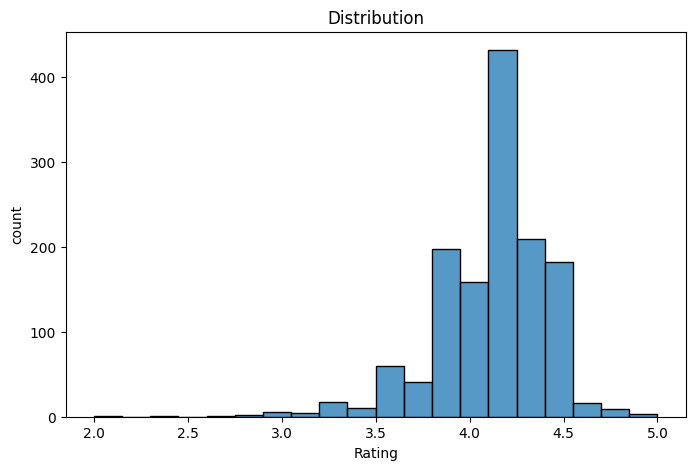

count    1350.000000
mean        4.091852
std         0.297444
min         2.000000
25%         3.900000
50%         4.100000
75%         4.300000
max         5.000000
Name: rating_num, dtype: float64


In [24]:
check_series_distribution(products_df['rating_num'],xlabel="Rating")

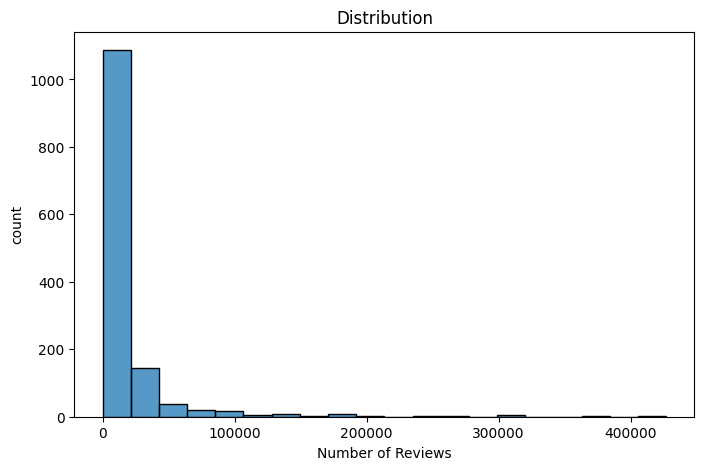

count      1349.000000
mean      17644.494440
std       42145.645569
min           2.000000
25%        1106.000000
50%        4740.000000
75%       16020.000000
max      426973.000000
Name: rating_count_num, dtype: float64


In [25]:
check_series_distribution(products_df['rating_count_num'],xlabel="Number of Reviews")

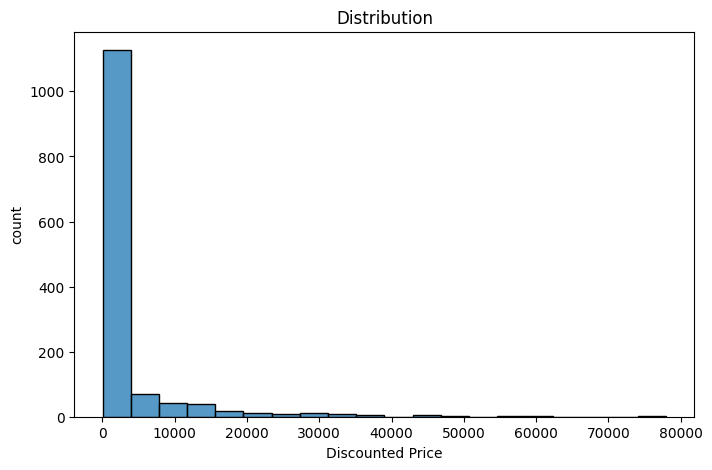

count     1351.000000
mean      3304.801754
std       7173.975455
min         39.000000
25%        349.000000
50%        899.000000
75%       2174.000000
max      77990.000000
Name: discounted_price_num, dtype: float64


In [26]:
check_series_distribution(products_df['discounted_price_num'],xlabel="Discounted Price")

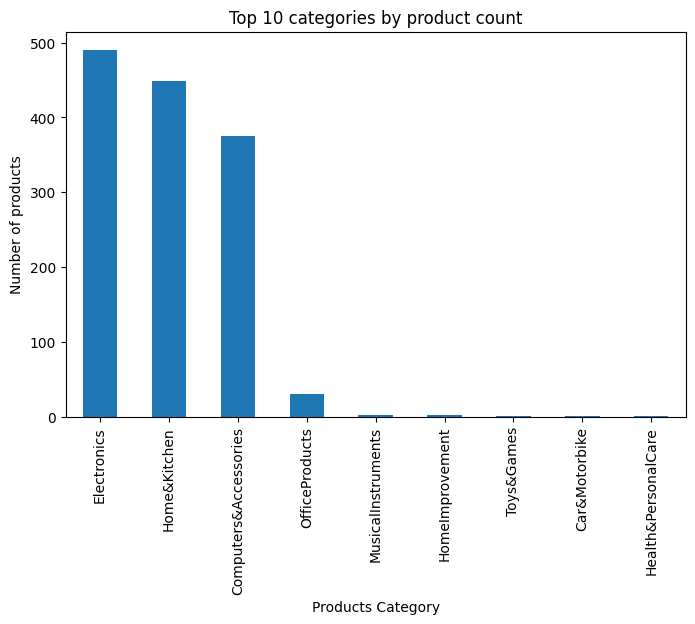

count      9.000000
mean     150.111111
std      217.830464
min        1.000000
25%        1.000000
50%        2.000000
75%      375.000000
max      490.000000
Name: count, dtype: float64


In [27]:
check_series_distribution(products_df['main_category'].value_counts().head(10),xlabel="Products Category",category_flag=1)

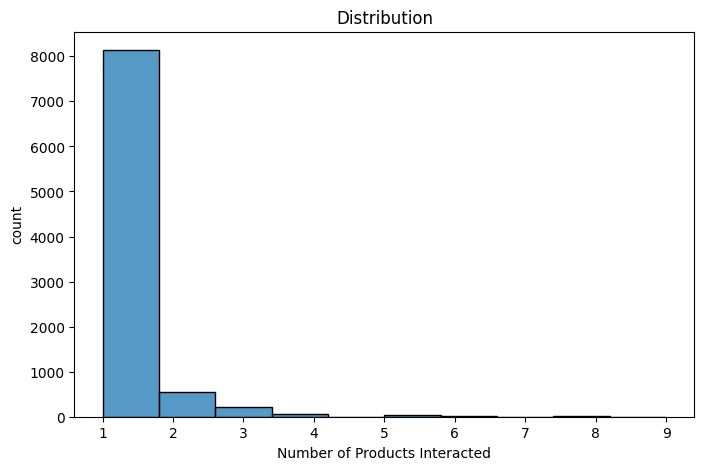

count    9050.000000
mean        1.171713
std         0.638157
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         9.000000
dtype: float64


In [28]:
check_series_distribution(interactions_df.groupby('user_id').size(), xlabel="Number of Products Interacted",bin_size=10)

1. Ratings are spread between 3 to 5 with no extreme skew towards 5-star ratings. Indicates ratings carry useful signal for product quality differentiation. We can safely use rating_num, weighted_rating as features because they carry meaningful variance.
2. Ratings count has a long tail distribution, which most marketplaces are affected(few products more reviews and many products less reviews). We must prevent popularity-bias, where only popular products get recommended. Features like weighted rating, recommender like hybrid recommender, and diversity re-ranking must be used.
3. Discounted prices has max(77990)>>>min(39), there are outliers in the data. Prices must be normalized, we must use price_bucket, discount_ratio, normalized price features for recommendation.
4. Product categories Electronics, Home&Kitchen, Computers&Accessories have higher products compared to others, content similarity can be weaker with bias towards these products. Possible mitigation can be category weighting, diversity re-ranking, hybrid recommendation.
5. Most users interact with only 1 product, Collaborative FIltering can be weak due to less overlap. User-based CF can be unreliable, so we can depend on content based filtering, Item-Item CF, Hybrid recommendation.

### EDA for business insights

In [29]:
products_df.columns

Index(['product_id', 'product_name', 'category', 'about_product', 'img_link',
       'product_link', 'discounted_price', 'actual_price',
       'discount_percentage', 'discounted_price_num', 'actual_price_num',
       'discount_percentage_num', 'price_difference', 'discount_ratio',
       'price_bucket', 'rating', 'rating_num', 'rating_count',
       'rating_count_num', 'value_for_money_score', 'weighted_rating',
       'main_category', 'secondary_category', 'category_l3', 'category_l4',
       'category_l5', 'category_l6'],
      dtype='object')

In [30]:
def most_reviewed_products(products:pd.DataFrame, top_n:int=10)->pd.DataFrame:
  cols=['product_id','product_name','rating_count_num']
  out=(
      products[cols].dropna(subset=['rating_count_num'])
      .sort_values('rating_count_num',ascending=False)
      .head(top_n)
      .reset_index(drop=True)
  )
  return out

In [31]:
most_reviewed_products(products_df)

,product_id,product_name,rating_count_num
0,B07KSMBL2H,AmazonBasics Flexible Premium HDMI Cable (Blac...,426973.0
1,B014I8SX4Y,"Amazon Basics High-Speed HDMI Cable, 6 Feet (2...",426973.0
2,B014I8SSD0,"Amazon Basics High-Speed HDMI Cable, 6 Feet - ...",426973.0
3,B07GQD4K6L,boAt Bassheads 100 in Ear Wired Earphones with...,363713.0
4,B07GPXXNNG,boAt Bassheads 100 in Ear Wired Earphones with...,363713.0
5,B071Z8M4KX,boAt BassHeads 100 in-Ear Wired Headphones wit...,363711.0
6,B09GFLXVH9,"Redmi 9A Sport (Coral Green, 2GB RAM, 32GB Sto...",313836.0
7,B09GFPVD9Y,"Redmi 9 Activ (Carbon Black, 4GB RAM, 64GB Sto...",313836.0
8,B09GFPN6TP,"Redmi 9A Sport (Coral Green, 3GB RAM, 32GB Sto...",313832.0
9,B09GFM8CGS,"Redmi 9A Sport (Carbon Black, 2GB RAM, 32GB St...",313832.0


In [32]:
def top_categories_by_num_of_prods(products:pd.DataFrame,top_n:int=10)->pd.DataFrame:
  out=products['main_category'].value_counts().sort_values(ascending=False).head(top_n)
  check_series_distribution(out,xlabel="Main Category",category_flag=1)
  return out

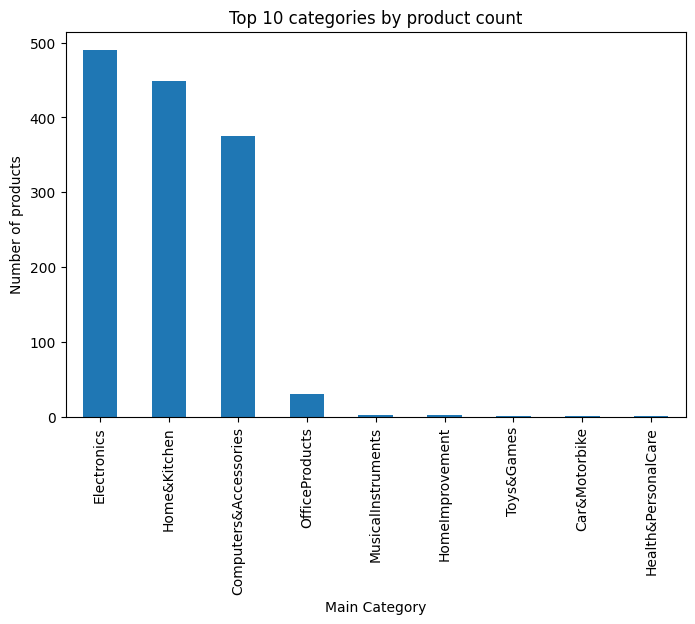

count      9.000000
mean     150.111111
std      217.830464
min        1.000000
25%        1.000000
50%        2.000000
75%      375.000000
max      490.000000
Name: count, dtype: float64


,count
main_category,
Electronics,490
Home&Kitchen,448
Computers&Accessories,375
OfficeProducts,31
MusicalInstruments,2
HomeImprovement,2
Toys&Games,1
Car&Motorbike,1
Health&PersonalCare,1


In [33]:
top_categories_by_num_of_prods(products_df)

In [34]:
def avg_rating_per_category(product:pd.DataFrame,top_n:int=10, plot:bool=True)->pd.DataFrame:
  out=(product.dropna(subset=['main_category','rating_num']).groupby('main_category').agg(
      avg_rating=("rating_num",'mean'),
      products=("product_id","nunique"),
      avg_review_count=("rating_count_num","mean")
  ).sort_values('avg_rating',ascending=False).head(top_n).reset_index())
  if plot:
    plt.figure(figsize=(8,5))
    plt.title(f"Top {top_n} rated categories")
    plt.bar(out['main_category'],out['avg_rating'])
    plt.xlabel("Main Category")
    plt.ylabel("Average Rating per Category")
    plt.xticks(rotation=90)
    plt.show()
  return out

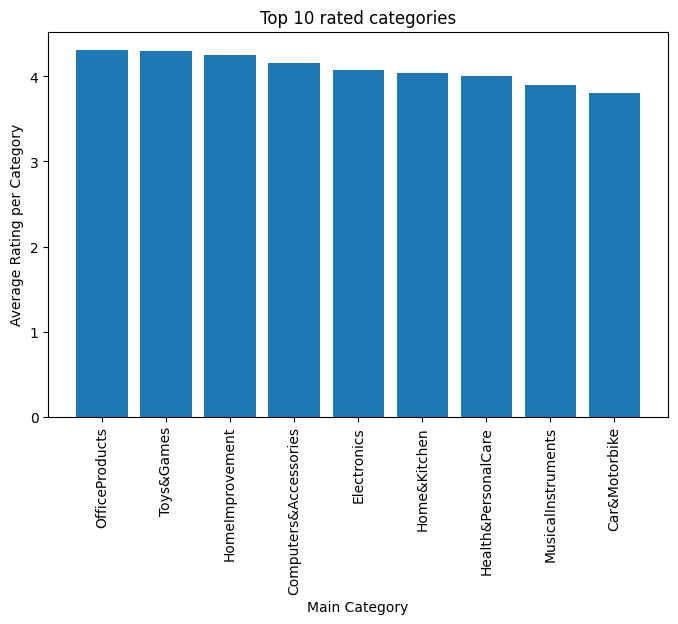

,main_category,avg_rating,products,avg_review_count
0,OfficeProducts,4.309677,31,4828.225806
1,Toys&Games,4.300000,1,15867.000000
2,HomeImprovement,4.250000,2,4283.000000
3,Computers&Accessories,4.153867,375,16984.388740
4,Electronics,4.077755,490,28996.746939
5,Home&Kitchen,4.040716,447,6689.210291
6,Health&PersonalCare,4.000000,1,3663.000000
7,MusicalInstruments,3.900000,2,44441.000000
8,Car&Motorbike,3.800000,1,1118.000000


In [35]:
avg_rating_per_category(products_df)

In [36]:
def safe_corr(a:pd.Series, b:pd.Series)->float:
  tmp=pd.concat([a,b],axis=1).dropna()
  if len(tmp)<3:
    return np.nan
  return float(tmp.corr().iloc[0,1])

In [37]:
def discount_vs_price(products:pd.DataFrame,plot:bool=True)->Dict:
  corr=safe_corr(products['discount_percentage_num'],products['actual_price_num'])
  if plot:
    tmp=products.dropna(subset=['discount_percentage_num','actual_price_num'])
    plt.figure(figsize=(8,5))
    # sns.scatterplot(data=tmp,x='actual_price_num',y='discount_percentage_num')
    plt.scatter(tmp['actual_price_num'],tmp['discount_percentage_num'],alpha=0.4)
    plt.title('Discounted percentage vs Actual Price')
    plt.ylabel('Discounted %')
    plt.xlabel('Actual Price')
    plt.show()
  return {'Discounted Percentage vs Actual Price Correlation':corr}

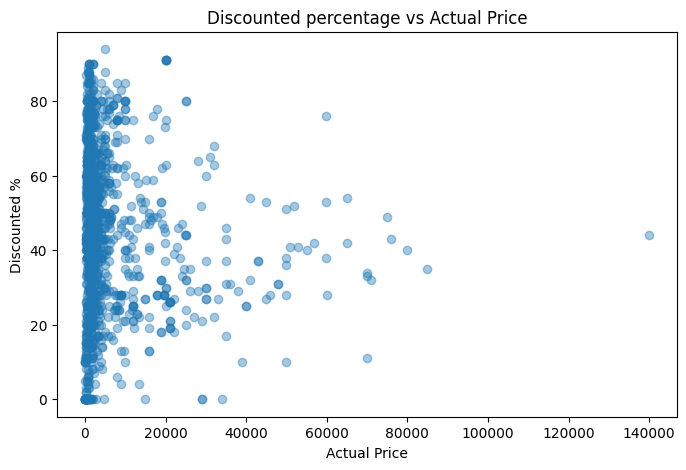

{'Discounted Percentage vs Actual Price Correlation': -0.11178624450294468}

In [38]:
discount_vs_price(products_df)

In [39]:
products_df.columns

Index(['product_id', 'product_name', 'category', 'about_product', 'img_link',
       'product_link', 'discounted_price', 'actual_price',
       'discount_percentage', 'discounted_price_num', 'actual_price_num',
       'discount_percentage_num', 'price_difference', 'discount_ratio',
       'price_bucket', 'rating', 'rating_num', 'rating_count',
       'rating_count_num', 'value_for_money_score', 'weighted_rating',
       'main_category', 'secondary_category', 'category_l3', 'category_l4',
       'category_l5', 'category_l6'],
      dtype='object')

In [40]:
def highrating_lowreviews(products:pd.DataFrame,min_rating:float=4.5,rating_count_threshold_quantile:float=0.25,top_n:int=10)->pd.DataFrame:
  tmp=products.dropna(subset=['rating_num','rating_count_num'])
  threshold=tmp['rating_count_num'].quantile(rating_count_threshold_quantile)

  out=tmp[(tmp['rating_num']>=min_rating) & (tmp['rating_count_num']<=threshold)].copy().sort_values(['rating_num','rating_count_num'],ascending=[False,True])
  cols=['product_id','product_name','main_category','rating_num','rating_count_num','discounted_price_num']
  return out[cols].head(top_n).reset_index(drop=True)

In [41]:
highrating_lowreviews(products_df)

,product_id,product_name,main_category,rating_num,rating_count_num,discounted_price_num
0,B0BP7XLX48,Syncwire LTG to USB Cable for Fast Charging Co...,Computers&Accessories,5.0,5.0,399.0
1,B09ZHCJDP1,Amazon Basics Wireless Mouse | 2.4 GHz Connect...,Computers&Accessories,5.0,23.0,499.0
2,B0BQ3K23Y1,"Oratech Coffee Frother electric, milk frother ...",Home&Kitchen,4.8,28.0,279.0
3,B0BLC2BYPX,Zuvexa USB Rechargeable Electric Foam Maker - ...,Home&Kitchen,4.7,54.0,499.0
4,B09P1MFKG1,Melbon VM-905 2000-Watt Room Heater (ISI Certi...,Home&Kitchen,4.6,9.0,998.0
5,B0BN6M3TCM,"VRPRIME Lint Roller Lint Remover for Clothes, ...",Home&Kitchen,4.6,79.0,499.0
6,B09JN37WBX,Lint Remover Woolen Clothes Lint Extractor Bat...,Home&Kitchen,4.6,124.0,319.0
7,B0BJ966M5K,Aquadpure Copper + Mineral RO+UV+UF 10 to 12 L...,Home&Kitchen,4.6,124.0,4999.0
8,B0B9BXKBC7,"WeCool S5 Long Selfie Stick, with Large Reinfo...",Electronics,4.6,245.0,1799.0
9,B0BNDD9TN6,WANBO X1 Pro (Upgraded) | Native 1080P Full HD...,Electronics,4.5,7.0,13990.0


In [42]:
def rating_vs_ratingcount(product:pd.DataFrame, plot:bool=True)->Dict:
  out=product.dropna(subset=['rating_num','rating_count_num'])
  corr=safe_corr(out['rating_num'],out['rating_count_num'])
  if plot:
    plt.figure(figsize=(8,5))
    plt.scatter(out['rating_num'],out['rating_count_num'],alpha=0.4)
    plt.title('Rating Count vs Rating')
    plt.xlabel('Rating')
    plt.ylabel('Rating Count')
    plt.show()
  return {'Correlation of Rating vs Rating Count':corr}

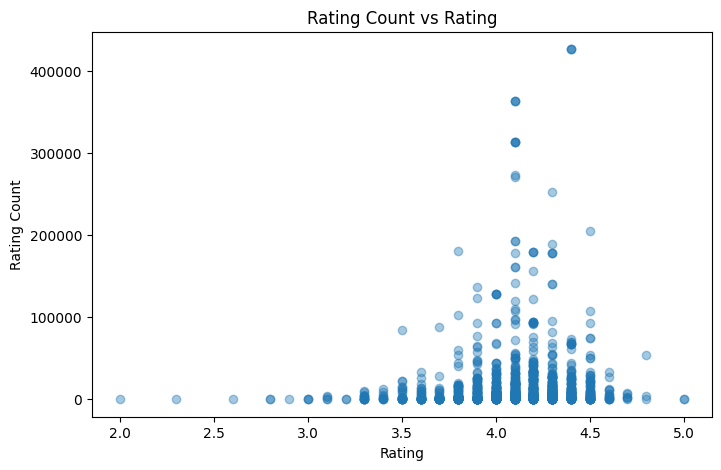

{'Correlation of Rating vs Rating Count': 0.09754997862614823}

In [43]:
rating_vs_ratingcount(products_df)

Insights:
1. Electronics, Home&Kitchen, and Computers&accessories have high number of products compared to others. Recommendation must include diversity re-ranking to avoid over-exposing to these categories.
2. Discount% vs Actual Price correlation is -0.11, which is very weak negative correlation. This suggests that discount strategy is not strongly tied to product price. Instead we need to focus more on discount_ratio, price_bucket, value_for_money_score features.
3. There are products with high ratings and low review counts, these can be good candidates for boosting in discovery modules. These products might be good but have low visibility, so can be used to include diversity.
4. Ratings vs rating count correlation=0.093, weak positive correlation. High ratings count doesn't necessarily mean high ratings. This is actually real marketplace behvior, not represent popularity bias. So rating count is not a reliable feature, but rather depend on weighted rating, that balances both rating and rating count features.

### Content-Based Recommendations

Decisions:
1. Content text=product_name, about_product, category_path, price_bucket, discount_bucket. To reflect both meaning and context.
2. Term Frequency-Inverse Document Frequency (TF-IDF) is used instead of embeddings. Because of small dataset.
3. Using cosine similarity because TF-IDF is highly dimensional and cosine is standard and stable.

In [44]:
products_df.columns

Index(['product_id', 'product_name', 'category', 'about_product', 'img_link',
       'product_link', 'discounted_price', 'actual_price',
       'discount_percentage', 'discounted_price_num', 'actual_price_num',
       'discount_percentage_num', 'price_difference', 'discount_ratio',
       'price_bucket', 'rating', 'rating_num', 'rating_count',
       'rating_count_num', 'value_for_money_score', 'weighted_rating',
       'main_category', 'secondary_category', 'category_l3', 'category_l4',
       'category_l5', 'category_l6'],
      dtype='object')

In [45]:
def build_content_text(products:pd.DataFrame)->pd.DataFrame:
  df=products.copy()
  df['product_name']=df['product_name'].fillna('')
  df['about_product']=df['about_product'].fillna('')
  if 'category_path' in df.columns:
    df['category_path']=df['category_path'].fillna('')
    category_text=df['category_path']
  else:
    df['main_category']=df['main_category'].fillna('')
    df['secondary_category']=df['secondary_category'].fillna('')
    category_text=df['main_category']+' '+df['secondary_category']
  df['price_bucket']=df.get('price_bucket','').astype(str).fillna('')
  df['discount_bucket']=pd.cut(
      df['discount_percentage_num'].fillna(0),
      bins=[-1,10,30,60,100],
      labels=['disc_low','disc_mid','disc_high','disc_very_high']
  ).astype(str)
  df['content_text']=(df['product_name'].astype(str)+' '+
                      df['about_product'].astype(str)+' '+
                      category_text.astype(str)+' '+
                      'price_'+df['price_bucket'].astype(str)+' '+
                      df['discount_bucket'].astype(str)
                      )
  df['content_text']=df['content_text'].str.replace(r'\s+', ' ',regex=True).str.strip()
  return df

In [46]:
def fit_tfidf_vectorizer(series:pd.Series,max_features:int=5000,ngram_range:Tuple[int,int]=(1,2))->Tuple[TfidfVectorizer,np.ndarray]:
  vectorizer=TfidfVectorizer(stop_words='english',max_features=max_features,ngram_range=ngram_range)
  tfidf_matrix=vectorizer.fit_transform(series)
  return vectorizer, tfidf_matrix

In [47]:
def compute_cosine_similarity(tfidf_matrix:np.ndarray)->np.ndarray:
  sim_matrix=cosine_similarity(tfidf_matrix,tfidf_matrix)
  return sim_matrix

In [48]:
def recommend_similar_products(products:pd.DataFrame,sim_matrix:np.ndarray,product_id:str,top_n:int=5)->pd.DataFrame:
  df=products.reset_index(drop=True).copy()
  id_to_idx={pid:i for i,pid in enumerate(df['product_id'].to_list())}
  if product_id not in id_to_idx:
    raise ValueError(f"{product_id} not present in products_df")
  idx=id_to_idx[product_id]#picking index of product_id
  scores=list(enumerate(sim_matrix[idx]))#enumerating similarity matrix of idx index->[(index,similarity_score),...]
  scores=sorted(scores,key= lambda x:x[1],reverse=True)#sort based on similarity score
  scores=[s for s in scores if s[0]!=idx][:top_n]#finding top_n scores not including the same product
  rec_idx=[i for i,_ in scores]#picking indices of top_n similar products
  rec_scores=[float(sc) for _,sc in scores]#picking similarity score of top_n similar products
  recs=df.loc[rec_idx,['product_id','product_name','main_category','discounted_price_num','rating_num']].copy()#picking other features from product_df
  recs['similarity_score']=rec_scores
  return recs.reset_index(drop=True)

In [49]:
products_cd=build_content_text(products_df)
vectorizer, tfidf_matrix=fit_tfidf_vectorizer(products_cd['content_text'])
sim_matrix=cosine_similarity(tfidf_matrix)

In [50]:
def find_lowest_rated_products(products:pd.DataFrame)->pd.Series:
  least_rating=products['rating_num'].dropna().min()
  return products[products['rating_num']==least_rating]['product_id']

In [51]:
def find_unrated_products(products:pd.DataFrame)->pd.Series:
  return products_df[products_df['rating_num'].isna()]['product_id']

In [52]:
# validating unrated products recommendations
test_pid=find_unrated_products(products_df).reset_index(drop=True).head(1).astype(str)[0]
recommend_similar_products(products_df,sim_matrix=sim_matrix,product_id=test_pid,top_n=5)

,product_id,product_name,main_category,discounted_price_num,rating_num,similarity_score
0,B08HDCWDXD,Eureka Forbes Active Clean 700 Watts Powerful ...,Home&Kitchen,3179.0,4.0,0.546039
1,B09FZ89DK6,Eureka Forbes Supervac 1600 Watts Powerful Suc...,Home&Kitchen,5999.0,4.2,0.544779
2,B00V9NHDI4,Eureka Forbes Trendy Zip 1000 Watts powerful s...,Home&Kitchen,2799.0,3.9,0.430210
3,B07Z51CGGH,Eureka Forbes Wet & Dry Ultimo 1400 Watts Mult...,Home&Kitchen,5499.0,3.8,0.388057
4,B072NCN9M4,AMERICAN MICRONIC- Imported Wet & Dry Vacuum C...,Home&Kitchen,8886.0,4.2,0.359380


In [53]:
products_df[products_df['product_id']==test_pid][['product_id','product_name','main_category','discounted_price_num','rating_num']]

,product_id,product_name,main_category,discounted_price_num,rating_num
1165,B08L12N5H1,Eureka Forbes car Vac 100 Watts Powerful Sucti...,Home&Kitchen,2099.0,NaN


In [54]:
# validating low rated products recommendations
test_pid=find_lowest_rated_products(products_df).reset_index(drop=True).head(1).astype(str)[0]
recommend_similar_products(products_df,sim_matrix=sim_matrix,product_id=test_pid,top_n=5)

,product_id,product_name,main_category,discounted_price_num,rating_num,similarity_score
0,B0BMZ6SY89,!!HANEUL!!1000 Watt/2000-Watt Room Heater!! Fa...,Home&Kitchen,899.0,3.4,0.457907
1,B0BMTZ4T1D,!!1000 Watt/2000-Watt Room Heater!! Fan Heater...,Home&Kitchen,784.0,4.5,0.446827
2,B00O24PUO6,Orpat OEH-1260 2000-Watt Fan Heater (Grey),Home&Kitchen,1464.0,4.1,0.425896
3,B08MZNT7GP,Havells OFR 13 Wave Fin with PTC Fan Heater 29...,Home&Kitchen,12499.0,4.1,0.384536
4,B08QHLXWV3,Kenstar 2400 Watts 9 Fins Oil Filled Radiator ...,Home&Kitchen,6850.0,3.9,0.381432


In [55]:
products_df[products_df['product_id']==test_pid][['product_id','product_name','main_category','discounted_price_num','rating_num']]

,product_id,product_name,main_category,discounted_price_num,rating_num
1195,B0BPJBTB3F,Khaitan ORFin Fan heater for Home and kitchen-...,Home&Kitchen,1299.0,2.0


1. Cold-start Product: TF-IDF correctly captured semantic similarity from product_name, about_product, category since all products belong to same category, similar function(vaccum cleaners), and similar attributes(HEPA filter, suction power, accessories). Though the price of product is only 2099, but range in recommendations is 2799 to 8886, this indicates moderate price expansion. Overall, TF-IDF performs well for cold-start products sinc eit depends mainly on metadata.
2. Low-rated Product: It recommended better rated products in rating range 3.4 to 4.5 compared to rating 2 of the product. Implying that it recommends high quality substitutes. Recommendations include different heaters, meaning not just product similarity but functional similarity is also covered by the model. But, the model also recommended products in price range of 784 to 12499 which include premium alternatives. This could be refined using price-aware ranking.

Limitations:
1. No personalization: different users receive the same product recommendations for the same product.
2. No behavioural insight: Model cannot learn patterns like "Customers who bought car vaccum cleaners also bought air purifiers together". This requires collaborative filtering. Though even User-User based collaborative filtering can perform poorly because of low average interactions per user(~1.27), so we might require a hybrid model.

### Collaborative Filtering (CF)

As already mentioned User-User CF is not a great choice for recommendations, we will go with item-item based CF because users might change but not items. Also, going with binary interaction matrix and not rating matrix as it is not user-specific.

In [56]:
def build_user_item_matrix(interactions:pd.DataFrame)->pd.DataFrame:
  df=interactions.copy()
  df['interaction_value']=1
  user_item=df.pivot_table(
      index='user_id',
      columns='product_id',
      values='interaction_value',
      aggfunc='max',
      fill_value=0
  )
  # print(user_item)
  return user_item

In [57]:
def compute_item_similarity(user_item_matrix:pd.DataFrame)->pd.DataFrame:
  item_user_matrix=user_item_matrix.T
  similarity=cosine_similarity(item_user_matrix)
  similarity_df=pd.DataFrame(similarity,index=item_user_matrix.index,columns=item_user_matrix.index)
  return similarity_df

In [58]:
def recommend_similar_items_cf(product_id:str,item_similairty_df:pd.DataFrame,products:pd.DataFrame,top_n:int=5)->pd.DataFrame:
  if product_id not in item_similairty_df.index:
    raise ValueError(f"{product_id} not found in item similarity matrix")
  sim_scores=item_similairty_df.loc[product_id].sort_values(ascending=False)
  sim_scores=sim_scores.drop(product_id, errors='ignore').head(top_n)
  recs_df=products[products['product_id'].isin(sim_scores.index)][['product_id','product_name','main_category','discounted_price_num','rating_num']].copy()
  recs_df['similarity_score']=recs_df['product_id'].map(sim_scores)
  recs_df=recs_df.sort_values('similarity_score',ascending=False).reset_index(drop=True)
  return recs_df

In [59]:
def recommend_for_user_item_cf(user_id:str,user_item_matrix:pd.DataFrame,item_similarity:pd.DataFrame,products:pd.DataFrame,top_n:int=5)->pd.DataFrame:
  if user_id not in user_item_matrix.index:
    raise ValueError(f"{user_id} not in user item matrix")
  user_vector=user_item_matrix.loc[user_id]
  seen_items=user_vector[user_vector>0].index.tolist()
  if len(seen_items)<1:
    raise ValueError(f"{user_id} has no interactions")
  score_series=pd.Series(0.0,index=item_similarity.index)
  for item in seen_items:
    score_series=score_series.add(item_similarity[item],fill_value=0)
  score_series=score_series.drop(labels=seen_items,errors='ignore')
  top_scores=score_series.sort_values(ascending=True).head(top_n)
  recs_df=products[products['product_id'].isin(top_scores.index)][['product_id','product_name','main_category','discounted_price_num','rating_num']].copy()
  recs_df['cf_score']=recs_df['product_id'].map(top_scores)
  recs_df=recs_df.sort_values('cf_score',ascending=False).reset_index(drop=True)
  return recs_df

In [60]:
def run_item_item_cf(interactions:pd.DataFrame,products:pd.DataFrame)->Tuple[pd.DataFrame,pd.DataFrame]:
  user_item_matrix=build_user_item_matrix(interactions)
  item_sim_matrix=compute_item_similarity(user_item_matrix)
  print('-----CF Report-----')
  print('user_item_matrix shape=',user_item_matrix.shape)
  print('item similarity matrix shape=',item_sim_matrix.shape)
  return user_item_matrix,item_sim_matrix

In [61]:
user_item_matrix, item_similarity_df=run_item_item_cf(interactions_df, products_df)

-----CF Report-----
user_item_matrix shape= (9050, 1351)
item similarity matrix shape= (1351, 1351)


In [62]:
products_df[products_df['rating_num']==4.7]

,product_id,product_name,category,about_product,img_link,product_link,discounted_price,actual_price,discount_percentage,discounted_price_num,...,rating_count,rating_count_num,value_for_money_score,weighted_rating,main_category,secondary_category,category_l3,category_l4,category_l5,category_l6
249,B09WN3SRC7,Sony Bravia 164 cm (65 inches) 4K Ultra HD Sma...,"Electronics|HomeTheater,TV&Video|Televisions|S...",Resolution: 4K Ultra HD (3840 x 2160) | Refres...,https://m.media-amazon.com/images/I/51uVckL1jR...,https://www.amazon.in/Sony-Bravia-inches-Googl...,"₹77,990","₹1,39,900",44%,77990.0,...,"5,935",5935.0,0.000060,4.340933,Electronics,"HomeTheater,TV&Video",Televisions,SmartTelevisions,NaN,NaN
446,B0B23LW7NV,Spigen EZ Fit Tempered Glass Screen Protector ...,Electronics|Mobiles&Accessories|MobileAccessor...,Compatibility ; Glass Screen Protector Compati...,https://m.media-amazon.com/images/I/51EiPNlJDg...,https://www.amazon.in/Spigen-Tempered-Screen-P...,₹999,"₹2,899",66%,999.0,...,"7,779",7779.0,0.004705,4.381061,Electronics,Mobiles&Accessories,MobileAccessories,"Maintenance,Upkeep&Repairs",ScreenProtectors,NaN
1109,B0BM4KTNL1,"FIGMENT Handheld Milk Frother Rechargeable, 3-...",Home&Kitchen|Kitchen&HomeAppliances|SmallKitch...,【Rechargeable Multi-Function Milk Frother】The ...,https://m.media-amazon.com/images/I/51oN+8Zs5Y...,https://www.amazon.in/FIGMENT-Rechargeable-Dec...,₹699,"₹1,599",56%,699.0,...,"1,729",1729.0,0.006724,4.196419,Home&Kitchen,Kitchen&HomeAppliances,SmallKitchenAppliances,HandBlenders,NaN,NaN
1112,B0BLC2BYPX,Zuvexa USB Rechargeable Electric Foam Maker - ...,Home&Kitchen|Kitchen&HomeAppliances|SmallKitch...,The food taste stainless steel whisking head i...,https://m.media-amazon.com/images/I/41714O1hnm...,https://www.amazon.in/Zuvexa-Rechargeable-Elec...,₹499,"₹1,299",62%,499.0,...,54,54.0,0.009419,4.100298,Home&Kitchen,Kitchen&HomeAppliances,SmallKitchenAppliances,HandBlenders,NaN,NaN
1161,B0BM9H2NY9,Multifunctional 2 in 1 Electric Egg Boiling St...,Home&Kitchen|Kitchen&HomeAppliances|SmallKitch...,Egg Frying Pan,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Multifunctional-Electric...,₹699,"₹1,599",56%,699.0,...,"2,300",2300.0,0.006724,4.222508,Home&Kitchen,Kitchen&HomeAppliances,SmallKitchenAppliances,EggBoilers,NaN,NaN
1274,B0BP89YBC1,Campfire Spring Chef Prolix Instant Portable W...,"Home&Kitchen|Heating,Cooling&AirQuality|WaterH...",Prolix Auto cut off feature: It is available w...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Spring-Chef-Stainless-Re...,"₹1,499","₹3,500",57%,1499.0,...,"2,591",2591.0,0.003135,4.234791,Home&Kitchen,"Heating,Cooling&AirQuality",WaterHeaters&Geysers,InstantWaterHeaters,NaN,NaN


In [63]:
#low rated product CF recommendation
test_pid=find_lowest_rated_products(products_df).reset_index(drop=True).head(1).astype(str)[0]
cf_prod_recs=recommend_similar_items_cf(test_pid,item_similarity_df,products_df)
cf_prod_recs

,product_id,product_name,main_category,discounted_price_num,rating_num,similarity_score
0,B09G5TSGXV,"Hi-Mobiler iPhone Charger Lightning Cable,2 Pa...",Computers&Accessories,254.0,4.0,0.0
1,B09GB5B4BK,HP 150 Wireless USB Mouse with Ergonomic and a...,Computers&Accessories,599.0,4.0,0.0
2,B09GBBJV72,HP 330 Wireless Black Keyboard and Mouse Set w...,Computers&Accessories,1409.0,3.9,0.0
3,B09FZ89DK6,Eureka Forbes Supervac 1600 Watts Powerful Suc...,Home&Kitchen,5999.0,4.2,0.0
4,B09G2VTHQM,"AGARO Classic Portable Yogurt Maker, 1.2L Capa...",Home&Kitchen,587.0,4.1,0.0


In [64]:
products_df[products_df['product_id']==test_pid][['product_id','product_name','main_category','discounted_price_num','rating_num']]

,product_id,product_name,main_category,discounted_price_num,rating_num
1195,B0BPJBTB3F,Khaitan ORFin Fan heater for Home and kitchen-...,Home&Kitchen,1299.0,2.0


In [65]:
interactions_df.columns

Index(['product_id', 'user_id', 'rating'], dtype='object')

In [66]:
#user level recommendation
user_id=interactions_df['user_id'].iloc[0]
cf_user_recs=recommend_for_user_item_cf(user_id,user_item_matrix,item_similarity_df,products_df)
cf_user_recs

,product_id,product_name,main_category,discounted_price_num,rating_num,cf_score
0,B09GFLXVH9,"Redmi 9A Sport (Coral Green, 2GB RAM, 32GB Sto...",Electronics,6499.0,4.1,0.0
1,B09GFM8CGS,"Redmi 9A Sport (Carbon Black, 2GB RAM, 32GB St...",Electronics,6499.0,4.1,0.0
2,B09GFN8WZL,Portronics Ruffpad 8.5M Multicolor LCD Writing...,Computers&Accessories,378.0,4.1,0.0
3,B09GBBJV72,HP 330 Wireless Black Keyboard and Mouse Set w...,Computers&Accessories,1409.0,3.9,0.0
4,B09FHHTL8L,Empty Mist Trigger Plastic Spray Bottle for Mu...,Home&Kitchen,85.0,4.1,0.0


In [67]:
products_of_user_id=interactions_df[interactions_df['user_id']==user_id]['product_id'].reset_index(drop=True).to_list()
# print(products_of_user_id)
products_df[products_df['product_id'].isin(products_of_user_id)][['product_id','product_name','main_category','discounted_price_num','rating_num']]

,product_id,product_name,main_category,discounted_price_num,rating_num
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories,399.0,4.2
42,B07JW1Y6XV,Wayona Nylon Braided 3A Lightning to USB A Syn...,Computers&Accessories,399.0,4.2
80,B07LGT55SJ,Wayona Usb Nylon Braided Data Sync And Chargin...,Computers&Accessories,399.0,4.2
89,B07JH1C41D,Wayona Nylon Braided (2 Pack) Lightning Fast U...,Computers&Accessories,649.0,4.2
106,B07JGDB5M1,Wayona Nylon Braided 2M / 6Ft Fast Charge Usb ...,Computers&Accessories,449.0,4.2
220,B07JH1CBGW,Wayona Nylon Braided Usb Syncing And Charging ...,Computers&Accessories,649.0,4.2


In both the cases (low-rated product and user based recommendation), the CF model has produced 0 CF_Score. This is due to sparse user-item interaction. This indicates that the dataset lacks enough user-item interactions to effectively learn behavioral similarity. As a result, CF couldn't provide meaningful recommendations in the dataset.
So we will move on to hybrid model approach, that combines content-based score, collaborative filtering score and quality signal(weighted rating).

### Hybrid Recommendation

Since content-based is strong because of product meta-data, TF-IDF recommendations were relevant, and works for cold-start products.
And, CF is weak due to sparse user-product interactions.
So, we make content-base as backboen and use CF wherever it behavioral signal exists. Then, add weighted rating to break ties and prefer higher quality, more reliable product.

Score formula: final_score=(0.7)X(content_score)+(0.2)X(cf_score)+(0.1)X(quality_score)

These weights are used because of strong content and weak CF models

In [68]:
def min_max_normalize(series:pd.Series)->pd.Series:
  s=series.copy()
  s=s.astype(float)
  if s.nunique(dropna=True)<=1:
    return pd.Series(0.0,index=s.index)
  return (s-s.min())/(s.max()-s.min())

In [69]:
def get_content_candidates(prod_id:str, products:pd.DataFrame,sim_matrix:np.ndarray,top_n:int=20):
  df=products.reset_index(drop=True).copy()
  id_to_idx={pid:i for i, pid in enumerate(df['product_id'].to_list())}
  if prod_id not in id_to_idx:
    raise ValueError(f"{prod_id} not found in Products")
  idx=id_to_idx[prod_id]
  scores=list(enumerate(sim_matrix[idx]))
  scores=sorted(scores,key=lambda x:x[1],reverse=True)
  scores=[s for s in scores if s[0]!=idx][:top_n]
  out=pd.DataFrame({
      "product_id":[df.loc[i,'product_id'] for i,_ in scores],
      "content_score_raw":[float(score) for _,score in scores]
  })
  return out

In [70]:
def get_cf_candidates(prod_id:str,item_similarity:pd.DataFrame,top_n:int=20)->pd.DataFrame:
  if prod_id not in item_similarity.index:
    return pd.DataFrame(columns=['product_id','cf_raw_score'])
  sim_scores=item_similarity.loc[prod_id].drop(columns='prod_id',errors='ignore')
  sim_scores=sim_scores.sort_values(ascending=False).head(top_n)
  out=pd.DataFrame({
      'product_id':sim_scores.index,
      'cf_raw_score':sim_scores.values.astype(float)
  })
  return out.reset_index(drop=True)

In [71]:
def recommend_hybrid_products(
    prod_id:str,
    products:pd.DataFrame,
    sim_matrix:np.ndarray,
    item_similarity:pd.DataFrame,
    top_n_candidates:int=30,
    top_n_final:int=5,
    w_content:float=0.7,
    w_cf:float=0.2,
    w_quality:float=0.1
)->pd.DataFrame:
  content_cands=get_content_candidates(
      prod_id,products,sim_matrix,top_n=top_n_candidates
  )
  cf_cands=get_cf_candidates(
      prod_id,item_similarity,top_n=top_n_candidates
  )
  # print(cf_cands.columns)
  hybrid=pd.merge(content_cands,cf_cands,on='product_id',how='outer')
  req_cols=['product_id','product_name','main_category','discounted_price_num','rating_num','weighted_rating']
  hybrid=hybrid.merge(products[req_cols],on='product_id',how='left')
  hybrid['content_score_raw']=hybrid['content_score_raw'].fillna(0.0)
  hybrid['cf_raw_score']=hybrid['cf_raw_score'].fillna(0.0)
  if 'weighted_rating' not in hybrid.columns and hybrid['weighted_rating'].notna().any():
    hybrid['quality_raw_score']=hybrid['weighted_rating'].fillna(hybrid['weighted_rating'].mean())
  else:
    hybrid['quality_raw_score']=hybrid['rating_num'].fillna(hybrid['rating_num'].mean())
  hybrid['content_score']=min_max_normalize(hybrid['content_score_raw'])
  hybrid['cf_score']=min_max_normalize(hybrid['cf_raw_score'])
  hybrid['quality_score']=min_max_normalize(hybrid['quality_raw_score'])
  hybrid['hybrid_score']=round(w_content*hybrid['content_score']+w_cf*hybrid['cf_score']+w_quality*hybrid['quality_score'],2)
  hybrid=hybrid.sort_values('hybrid_score',ascending=False).head(top_n_final).reset_index(drop=True)
  return hybrid[['product_id','product_name','main_category','discounted_price_num','rating_num','content_score_raw','cf_raw_score','quality_raw_score','hybrid_score']]

In [72]:
#cold start products
prod_id=find_unrated_products(products_df).reset_index(drop=True).head(1).astype(str)[0]
hybrid_recs_unrated=recommend_hybrid_products(prod_id,products_df,sim_matrix,item_similarity_df,top_n_candidates=30,top_n_final=5)
hybrid_recs_unrated

,product_id,product_name,main_category,discounted_price_num,rating_num,content_score_raw,cf_raw_score,quality_raw_score,hybrid_score
0,B09FZ89DK6,Eureka Forbes Supervac 1600 Watts Powerful Suc...,Home&Kitchen,5999.0,4.2,0.544779,0.0,4.2,0.78
1,B08HDCWDXD,Eureka Forbes Active Clean 700 Watts Powerful ...,Home&Kitchen,3179.0,4.0,0.546039,0.0,4.0,0.77
2,B00V9NHDI4,Eureka Forbes Trendy Zip 1000 Watts powerful s...,Home&Kitchen,2799.0,3.9,0.430210,0.0,3.9,0.62
3,B07Z51CGGH,Eureka Forbes Wet & Dry Ultimo 1400 Watts Mult...,Home&Kitchen,5499.0,3.8,0.388057,0.0,3.8,0.55
4,B072NCN9M4,AMERICAN MICRONIC- Imported Wet & Dry Vacuum C...,Home&Kitchen,8886.0,4.2,0.359380,0.0,4.2,0.55


In [73]:
products_df[products_df['product_id']==prod_id][['product_id','product_name','main_category','discounted_price_num','rating_num']]

,product_id,product_name,main_category,discounted_price_num,rating_num
1165,B08L12N5H1,Eureka Forbes car Vac 100 Watts Powerful Sucti...,Home&Kitchen,2099.0,NaN


In [74]:
#low rated products
prod_id=find_lowest_rated_products(products_df).reset_index(drop=True).head(1).astype(str)[0]
hybrid_recs_low_rated=recommend_hybrid_products(prod_id,products_df,sim_matrix,item_similarity_df,top_n_candidates=30,top_n_final=5)
hybrid_recs_low_rated

,product_id,product_name,main_category,discounted_price_num,rating_num,content_score_raw,cf_raw_score,quality_raw_score,hybrid_score
0,B0BMTZ4T1D,!!1000 Watt/2000-Watt Room Heater!! Fan Heater...,Home&Kitchen,784.0,4.5,0.446827,0.0,4.5,0.78
1,B0BMZ6SY89,!!HANEUL!!1000 Watt/2000-Watt Room Heater!! Fa...,Home&Kitchen,899.0,3.4,0.457907,0.0,3.4,0.75
2,B00O24PUO6,Orpat OEH-1260 2000-Watt Fan Heater (Grey),Home&Kitchen,1464.0,4.1,0.425896,0.0,4.1,0.73
3,B08MZNT7GP,Havells OFR 13 Wave Fin with PTC Fan Heater 29...,Home&Kitchen,12499.0,4.1,0.384536,0.0,4.1,0.67
4,B08QHLXWV3,Kenstar 2400 Watts 9 Fins Oil Filled Radiator ...,Home&Kitchen,6850.0,3.9,0.381432,0.0,3.9,0.66


In [75]:
products_df[products_df['product_id']==prod_id][['product_id','product_name','main_category','discounted_price_num','rating_num']]

,product_id,product_name,main_category,discounted_price_num,rating_num
1195,B0BPJBTB3F,Khaitan ORFin Fan heater for Home and kitchen-...,Home&Kitchen,1299.0,2.0


# Insights
Though the hybrid recommender is based on content, CF, quality; it was able to derive recommendations from content and quality. Due to sparse interactions in the dataset, it is unable to effectively use CF to drive recommendations. This architecture ensures robust recommendations even for cold-start products while remaining extensible for future behavioral data.

Let us tweak CF process to find hidden factors behind products and users. I will use matrix factorization to find this unlike memory-based CF that required overlap.
Matrix Factorization is good because it learns:
1. compressed user space
2. compressed product space
3. hidden relationships

In [76]:
def build_user_item_matrix_mf(interactions:pd.DataFrame)->pd.DataFrame:
  df=interactions.copy()
  if 'rating' in df.columns:
    df['interaction_value']=df['rating'].fillna(0.0)
  else:
    df['interaction_value']=1.0
  user_item=df.pivot_table(
      index='user_id',
      columns='product_id',
      values='interaction_value',
      fill_value=0
  )
  return user_item

In [77]:
def fit_svd_recommender(
    user_item_matrix:pd.DataFrame,
    n_components:int=50,
    random_state:int=42
)->Tuple[TruncatedSVD,np.ndarray,np.array,np.ndarray]:
  X=user_item_matrix.values
  svd=TruncatedSVD(
      n_components=n_components,
      random_state=random_state
  )
  user_factors=svd.fit_transform(X)
  item_factors=svd.components_.T
  reconstructed=np.dot(user_factors,item_factors.T)
  return svd, user_factors, item_factors, reconstructed

In [78]:
def build_predicted_score_df(user_item_matrix:pd.DataFrame,reconstructed_matrix:np.ndarray)->pd.DataFrame:
  pred_df=pd.DataFrame(
      reconstructed_matrix,
      index=user_item_matrix.index,
      columns=user_item_matrix.columns
  )
  return pred_df

In [79]:
def recommend_for_user_svd(
    user_id:str,
    user_item_matrix:pd.DataFrame,
    predicted_scores_df:pd.DataFrame,
    products:pd.DataFrame,
    top_n:int=5
)->pd.DataFrame:
  if user_id not in user_item_matrix.index:
    raise ValueError(f"{user_id} not in user_item_matrix")
  seen_items=user_item_matrix.loc[user_id]
  seen_items=seen_items[seen_items>0].index.tolist()
  user_scores=predicted_scores_df.loc[user_id].copy()
  user_scores=user_scores.drop(labels=seen_items,errors='ignore')
  top_scores=user_scores.sort_values(ascending=False).head(top_n)
  recs=products[products['product_id'].isin(top_scores.index)][['product_id','product_name','main_category','discounted_price_num','rating_num']].copy()
  recs['svd_score']=recs['product_id'].map(top_scores)
  recs=recs.sort_values('svd_score',ascending=False).reset_index(drop=True)
  return recs

In [80]:
def build_item_latent_similarity(user_item_matrix:pd.DataFrame,item_factors:np.ndarray)->pd.DataFrame:
  sim=cosine_similarity(item_factors)
  sim_df=pd.DataFrame(
      sim,
      index=user_item_matrix.columns,
      columns=user_item_matrix.columns
  )
  return sim_df

In [81]:
def recommend_similar_items_svd(
    prod_id:str,
    item_latent_sim_df:pd.DataFrame,
    products:pd.DataFrame,
    top_n:int=5
)->pd.DataFrame:
  if prod_id not in item_latent_sim_df.index:
    raise ValueError(f"{prod_id} not in item_latent_sim_df")
  scores=item_latent_sim_df.loc[prod_id].drop(prod_id,errors='ignore')
  top_scores=scores.sort_values(ascending=False).head(top_n)
  recs=products[products['product_id'].isin(top_scores.index)][['product_id','product_name','main_category','discounted_price_num','rating_num']].copy()
  recs['latent_similarity_score']=recs['product_id'].map(top_scores)
  recs=recs.sort_values('latent_similarity_score',ascending=False).reset_index(drop=True)
  return recs

In [82]:
user_item_mf=build_user_item_matrix_mf(interactions_df)
svd_model,user_factors,item_factors,reconstructed=fit_svd_recommender(user_item_mf,n_components=80,random_state=42)
predicted_scores_df=build_predicted_score_df(user_item_mf,reconstructed)
item_latent_sim_df=build_item_latent_similarity(user_item_mf,item_factors)
print("user_item_mf shape:", user_item_mf.shape)
print("user_factors shape:", user_factors.shape)
print("item_factors shape:", item_factors.shape)
print("predicted_scores_df shape:", predicted_scores_df.shape)

user_item_mf shape: (9050, 1351)
user_factors shape: (9050, 80)
item_factors shape: (1351, 80)
predicted_scores_df shape: (9050, 1351)


In [83]:
#user-level svd recommendations
sample_user=interactions_df['user_id'].iloc[0]
svd_user_recs=recommend_for_user_svd(
    user_id=sample_user,
    user_item_matrix=user_item_mf,
    predicted_scores_df=predicted_scores_df,
    products=products_df,
    top_n=5
)
svd_user_recs

,product_id,product_name,main_category,discounted_price_num,rating_num,svd_score
0,B097C564GC,"rts [2 Pack] Mini USB C Type C Adapter Plug, T...",Computers&Accessories,294.0,4.3,0.646046
1,B09M869Z5V,Portronics MPORT 31C 4-in-1 USB Hub (Type C to...,Computers&Accessories,570.0,4.2,0.016165
2,B08H9Z3XQW,boAt Bassheads 242 in Ear Wired Earphones with...,Electronics,455.0,4.1,0.004758
3,B07S9S86BF,boAt Bassheads 242 in Ear Wired Earphones with...,Electronics,599.0,4.1,0.004758
4,B095JQVC7N,OnePlus 138.7 cm (55 inches) U Series 4K LED S...,Electronics,42999.0,4.1,0.004370


Matrix Factorization(MF) using Truncated SVD produced results with non-zero scores. For a user level, the 1st recommendation had high score but then scores have collapsed. This means the model doesn't have strong structure beyond that. This is due to SVD still depending on user-item interactions, which is sparse in the dataset.

In [84]:
#product level latent recommendations
low_prod_id=find_lowest_rated_products(products_df).reset_index(drop=True).head(1).astype(str)[0]
svd_item_recs=recommend_similar_items_svd(
    prod_id=low_prod_id,
    item_latent_sim_df=item_latent_sim_df,
    products=products_df,
    top_n=5
)
svd_item_recs

,product_id,product_name,main_category,discounted_price_num,rating_num,latent_similarity_score
0,B09NC2TY11,Noise ColorFit Ultra Buzz Bluetooth Calling Sm...,Electronics,2499.0,4.1,0.507392
1,B01LWYDEQ7,Pigeon Polypropylene Mini Handy and Compact Ch...,Home&Kitchen,199.0,4.1,0.494501
2,B00NM6MO26,Prestige PIC 16.0+ 1900W Induction Cooktop wit...,Home&Kitchen,2698.0,4.0,0.486975
3,B08R69VDHT,Pinnaclz Original Combo of 2 Micro USB Fast Ch...,Computers&Accessories,115.0,4.0,0.473158
4,B08R69WBN7,Pinnaclz Original Combo of 2 USB Type C Fast C...,Computers&Accessories,149.0,4.0,0.473158


In [85]:
products_df[products_df['product_id']==low_prod_id][['product_id','product_name','main_category','discounted_price_num','rating_num']]

,product_id,product_name,main_category,discounted_price_num,rating_num
1195,B0BPJBTB3F,Khaitan ORFin Fan heater for Home and kitchen-...,Home&Kitchen,1299.0,2.0


For item-latent similarity, the recommendations are not functionally related. This means the model did not learn a coherent product cluster.

In [86]:
def evaluate_svd_components(user_item_matrix,component_grid=None,random_state=42):
  if component_grid is None:
    component_grid=[10,20,30,40,50,60,70,80,100]
  X=user_item_matrix.values
  results=[]
  for n in component_grid:
    svd=TruncatedSVD(n_components=n,random_state=random_state)
    svd.fit(X)
    explained_var=svd.explained_variance_ratio_.sum()
    results.append({
        "n_components":n,
        "explained_variance":explained_var
    })
  results_df=pd.DataFrame(results)
  return results_df

In [87]:
def plot_svd_explained_variance(results_df):
    plt.figure(figsize=(8, 5))
    plt.plot(results_df["n_components"], results_df["explained_variance"], marker="o")
    plt.title("SVD Explained Variance vs Number of Components")
    plt.xlabel("n_components")
    plt.ylabel("Cumulative Explained Variance")
    plt.grid(True)
    plt.show()

   n_components  explained_variance
0            20            0.070939
1            40            0.115718
2            60            0.149322
3            80            0.180517
4           100            0.205771
5           120            0.224971
6           140            0.243009
7           160            0.260846
8           180            0.278270
9           200            0.295549


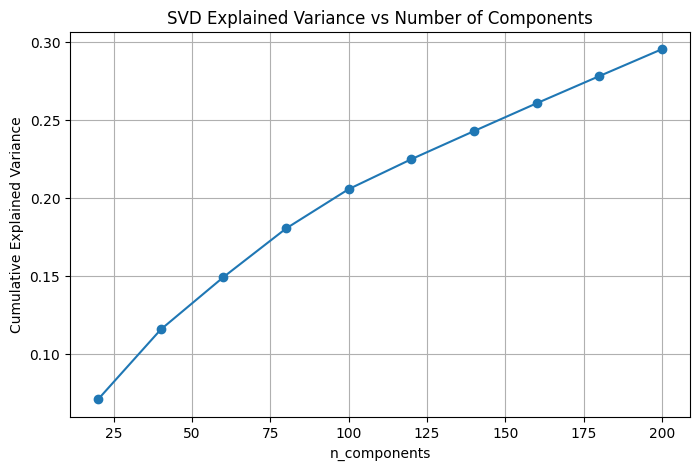

In [88]:
svd_eval_df = evaluate_svd_components(
    user_item_matrix=user_item_mf,
    component_grid=[20,40,60,80,100,120,140,160,180,200]
)

print(svd_eval_df)
plot_svd_explained_variance(svd_eval_df)

The optimal number of latent factors is explored using cumilative variance across different component sizes. Due to extreme sparsity in interaction matrix, the variance increased gradually without an elbow point. Therefor, a mid-range value of 80 components was selected so as to balance model's expressiveness and overfitting risk. Increasing number of points beyond this would only give marginal variance gains.

## **Insights from different models**
1. The limitation is not in the algorithm but in the dataset.
2. It behaves like a product-catalog and not like a user behavior dataset.
3. Typical recommender dataset contains: millions of interactions, repeated purchases, session data, clickstream but our data mainly has product metadata, product reviews. So, content based learning majorly dominates.

### Multiple CF approaches were explored including item-item similarity and Matrix Factorization using SVD. However, due to extreme sparsity in interactions data(~1.7 product interactions per user), CF models produced weak signals. Content based similarity using product metadata proved more reliable. Therfore hybrid approach is employed that combines content based with CF & quality signals.

In [89]:
def get_mf_candidates(prod_id:str,products:pd.DataFrame,item_factors:np.ndarray,top_n:int=30)->pd.DataFrame:
  prod_idx=products.index[products['product_id']==prod_id]
  if len(prod_idx)==0:
    return pd.DataFrame(columns=['product_id','mf_raw_score'])
  prod_idx=prod_idx[0]
  target_vector=item_factors[prod_idx].reshape(1,-1)
  similarity_scores=cosine_similarity(target_vector,item_factors).flatten()
  mf_df=pd.DataFrame({
      'product_id':products['product_id'],
      'mf_raw_score':similarity_scores
  })
  mf_df=mf_df[mf_df['product_id']!=prod_id]
  mf_df=mf_df.sort_values('mf_raw_score',ascending=False)
  return mf_df.head(top_n)

In [90]:
# adding mf to hybrid approach
def recommend_hybrid_products_v2(
    prod_id:str,
    products:pd.DataFrame,
    sim_matrix:np.ndarray,
    item_similarity:pd.DataFrame,
    item_factors:np.ndarray,
    top_n_candidates:int=30,
    top_n_final:int=5,
    w_content:float=0.65,
    w_cf:float=0.1,
    w_mf:float=0.15,
    w_quality:float=0.1,
    reranking:bool=False
)->pd.DataFrame:
  content_cands=get_content_candidates(
      prod_id,products,sim_matrix,top_n=top_n_candidates
  )
  cf_cands=get_cf_candidates(
      prod_id,item_similarity,top_n=top_n_candidates
  )
  mf_cands=get_mf_candidates(prod_id,products,item_factors,top_n=top_n_candidates)

  hybrid=pd.merge(content_cands,cf_cands,on='product_id',how='outer')
  hybrid=pd.merge(hybrid,mf_cands,on='product_id',how='outer')

  req_cols=['product_id','product_name','main_category','discounted_price_num','rating_num','weighted_rating']
  hybrid=hybrid.merge(products[req_cols],on='product_id',how='left')

  hybrid['content_score_raw']=hybrid['content_score_raw'].fillna(0.0)
  hybrid['cf_raw_score']=hybrid['cf_raw_score'].fillna(0.0)
  hybrid['mf_raw_score']=hybrid['mf_raw_score'].fillna(0.0)

  if 'weighted_rating' not in hybrid.columns and hybrid['weighted_rating'].notna().any():
    hybrid['quality_raw_score']=hybrid['weighted_rating'].fillna(hybrid['weighted_rating'].mean())
  else:
    hybrid['quality_raw_score']=hybrid['rating_num'].fillna(hybrid['rating_num'].mean())

  hybrid['content_score']=min_max_normalize(hybrid['content_score_raw'])
  hybrid['cf_score']=min_max_normalize(hybrid['cf_raw_score'])
  hybrid['quality_score']=min_max_normalize(hybrid['quality_raw_score'])
  hybrid['mf_score']=min_max_normalize(hybrid['mf_raw_score'])
  hybrid['hybrid_score']=round(w_content*hybrid['content_score']+w_cf*hybrid['cf_score']+w_quality*hybrid['quality_score']+w_mf*hybrid['mf_score'],2)
  if reranking:
    hybrid=hybrid.sort_values('hybrid_score',ascending=False).reset_index(drop=True)
  else:
    hybrid=hybrid.sort_values('hybrid_score',ascending=False).head(top_n_final).reset_index(drop=True)
  return hybrid[['product_id','product_name','main_category','discounted_price_num','rating_num','content_score_raw','cf_raw_score','mf_raw_score','quality_raw_score','hybrid_score']]

In [91]:
#cold start products
prod_id=find_unrated_products(products_df).reset_index(drop=True).head(1).astype(str)[0]
hybrid_recs_unrated=recommend_hybrid_products_v2(prod_id,products_df,sim_matrix,item_similarity_df,item_factors,top_n_candidates=30,top_n_final=5)
hybrid_recs_unrated

,product_id,product_name,main_category,discounted_price_num,rating_num,content_score_raw,cf_raw_score,mf_raw_score,quality_raw_score,hybrid_score
0,B09FZ89DK6,Eureka Forbes Supervac 1600 Watts Powerful Suc...,Home&Kitchen,5999.0,4.2,0.544779,0.0,0.0,4.2,0.72
1,B08HDCWDXD,Eureka Forbes Active Clean 700 Watts Powerful ...,Home&Kitchen,3179.0,4.0,0.546039,0.0,0.0,4.0,0.71
2,B00V9NHDI4,Eureka Forbes Trendy Zip 1000 Watts powerful s...,Home&Kitchen,2799.0,3.9,0.430210,0.0,0.0,3.9,0.57
3,B07Z51CGGH,Eureka Forbes Wet & Dry Ultimo 1400 Watts Mult...,Home&Kitchen,5499.0,3.8,0.388057,0.0,0.0,3.8,0.51
4,B072NCN9M4,AMERICAN MICRONIC- Imported Wet & Dry Vacuum C...,Home&Kitchen,8886.0,4.2,0.359380,0.0,0.0,4.2,0.50


In [92]:
#low rated products
prod_id=find_lowest_rated_products(products_df).reset_index(drop=True).head(1).astype(str)[0]
hybrid_recs_low_rated=recommend_hybrid_products_v2(prod_id,products_df,sim_matrix,item_similarity_df,item_factors,top_n_candidates=30,top_n_final=5)
hybrid_recs_low_rated

,product_id,product_name,main_category,discounted_price_num,rating_num,content_score_raw,cf_raw_score,mf_raw_score,quality_raw_score,hybrid_score
0,B0BMTZ4T1D,!!1000 Watt/2000-Watt Room Heater!! Fan Heater...,Home&Kitchen,784.0,4.5,0.446827,0.0,0.0,4.5,0.73
1,B0BMZ6SY89,!!HANEUL!!1000 Watt/2000-Watt Room Heater!! Fa...,Home&Kitchen,899.0,3.4,0.457907,0.0,0.0,3.4,0.70
2,B00O24PUO6,Orpat OEH-1260 2000-Watt Fan Heater (Grey),Home&Kitchen,1464.0,4.1,0.425896,0.0,0.0,4.1,0.69
3,B08MZNT7GP,Havells OFR 13 Wave Fin with PTC Fan Heater 29...,Home&Kitchen,12499.0,4.1,0.384536,0.0,0.0,4.1,0.63
4,B08QHLXWV3,Kenstar 2400 Watts 9 Fins Oil Filled Radiator ...,Home&Kitchen,6850.0,3.9,0.381432,0.0,0.0,3.9,0.61


In [93]:
#random product
test_pid=products_df['product_id'].iloc[np.random.choice(len(products_df))]
hybrid_recs=recommend_hybrid_products_v2(test_pid,products_df,sim_matrix,item_similarity_df,item_factors,top_n_candidates=30,top_n_final=5)
hybrid_recs

,product_id,product_name,main_category,discounted_price_num,rating_num,content_score_raw,cf_raw_score,mf_raw_score,quality_raw_score,hybrid_score
0,B09NVPSCQT,Noise ColorFit Pulse Grand Smart Watch with 1....,Electronics,1599.0,4.0,0.499236,0.0,0.0,4.0,0.72
1,B09NVPJ3P4,Noise ColorFit Pulse Grand Smart Watch with 1....,Electronics,1999.0,4.0,0.482815,0.0,0.0,4.0,0.70
2,B09PNKXSKF,Noise ColorFit Pulse Grand Smart Watch with 1....,Electronics,1999.0,4.0,0.461853,0.0,0.0,4.0,0.67
3,B09BNXQ6BR,"Noise ColorFit Ultra SE Smart Watch with 1.75""...",Electronics,2799.0,4.1,0.430968,0.0,0.0,4.1,0.63
4,B09MQSCJQ1,"boAt Xtend Smartwatch with Alexa Built-in, 1.6...",Electronics,2299.0,4.2,0.402082,0.0,0.0,4.2,0.60


Even with MF the scores don't make much difference, from very bad signal of CF, it improved to a very weak signal. Again, it is the sparsity issue of the dataset and not the model issue.
The final signal is dominated by the content signals.

### Re-ranking, Diversity Layer

Right now, the recommendations have following issues:
1. Too-many near duplicate items
2. products far outside the price band
3. Not enough catalog exploration

To counter these, we add 3 controls:
1. Diversity control
2. Price compatibility
3. Popularity Balancing

So the final_score looks like: final_score=hybrid_score-diversity_penalty-repition_penalty+quality_bonus

In [94]:
def compute_price_penalty(candidate_price:float, seed_price:float)->float:
  if pd.isna(candidate_price) or pd.isna(seed_price) or seed_price<=0:
    return 0.0
  relative_diff=abs(candidate_price-seed_price)/seed_price
  return min(relative_diff,1.0)

In [95]:
def rerank_hybrid_candidates(
    seed_prod_id:str,
    candidates_df:pd.DataFrame,
    products:pd.DataFrame,
    top_n:int=5,
    price_penalty_weight:float=0.15,
    repitition_penalty_weight:float=0.10,
    quality_bonus_weight:float=0.05
)->pd.DataFrame:
  candidates=candidates_df.copy()
  seed_row=products[products['product_id']==seed_prod_id]
  if len(seed_row)==0:
    raise ValueError(f"{seed_prod_id} not present in products")
  seed_price=seed_row['discounted_price_num'].iloc[0]
  seed_category=seed_row['main_category'].iloc[0]
  selected_rows=[]
  selected_categories=[]
  price_lower_bound=0.5*seed_price
  price_upper_bound=2.5*seed_price
  candidates=candidates[(candidates['discounted_price_num']>=price_lower_bound) & (candidates['discounted_price_num']<=price_upper_bound)]
  candidates['price_penalty']=candidates['discounted_price_num'].apply(lambda x:compute_price_penalty(x,seed_price))
  candidates['quality_bonus']=min_max_normalize(candidates['quality_raw_score'].fillna(candidates['quality_raw_score'].mean()))

  remaining=candidates.copy()
  while len(selected_rows)<top_n and len(remaining)>0:
    temp=remaining.copy()
    temp['repetition_penalty']=temp['main_category'].apply(lambda x: 1.0 if x in selected_categories else 0.0)
    temp['final_score']=temp['hybrid_score']-price_penalty_weight*temp['price_penalty']-repitition_penalty_weight*temp['repetition_penalty']+quality_bonus_weight*temp['quality_bonus']
    best_idx=temp['final_score'].idxmax()
    best_row=temp.loc[best_idx]
    selected_rows.append(best_row)
    selected_categories.append(best_row['main_category'])
    remaining=remaining.drop(index=best_idx)
  reranked=pd.DataFrame(selected_rows).reset_index(drop=True)

  return reranked[['product_id','product_name','main_category','discounted_price_num', 'rating_num','hybrid_score', 'price_penalty','repetition_penalty', 'quality_bonus', 'final_score']]

In [96]:
def recommend_reranked_hybrid_products(
    prod_id:str,
    products:pd.DataFrame,
    sim_matrix:np.ndarray,
    item_similarity:pd.DataFrame,
    item_factors:np.ndarray,
    top_n_candidates:int=30,
    top_n_final:int=5,
    w_content:float=0.65,
    w_cf:float=0.1,
    w_mf:float=0.15,
    w_quality:float=0.1,
    price_penalty_weight:float=0.15,
    repitition_penalty_weight:float=0.10,
    quality_bonus_weight:float=0.05,
    reranking:bool=True
)->pd.DataFrame:
  candidate_pool=recommend_hybrid_products_v2(prod_id=prod_id,products=products,sim_matrix=sim_matrix,item_similarity=item_similarity,item_factors=item_factors,top_n_candidates=top_n_candidates,reranking=reranking)
  reranked=rerank_hybrid_candidates(seed_prod_id=prod_id,candidates_df=candidate_pool,products=products,top_n=top_n_final,price_penalty_weight=price_penalty_weight,repitition_penalty_weight=repitition_penalty_weight,quality_bonus_weight=quality_bonus_weight)
  return reranked

In [97]:
# unrated product recommendations
prod_id=find_unrated_products(products_df).reset_index(drop=True).head(1).astype(str)[0]
reranked_unrated = recommend_reranked_hybrid_products(
    prod_id=prod_id,
    products=products_cd,
    sim_matrix=sim_matrix,
    item_similarity=item_similarity_df,
    item_factors=item_factors,
    top_n_candidates=30,
    top_n_final=5
)
reranked_unrated

,product_id,product_name,main_category,discounted_price_num,rating_num,hybrid_score,price_penalty,repetition_penalty,quality_bonus,final_score
0,B08HDCWDXD,Eureka Forbes Active Clean 700 Watts Powerful ...,Home&Kitchen,3179.0,4.0,0.71,0.514531,0.0,0.625,0.664070
1,B00V9NHDI4,Eureka Forbes Trendy Zip 1000 Watts powerful s...,Home&Kitchen,2799.0,3.9,0.57,0.333492,1.0,0.500,0.444976
2,B0B1MDZV9C,"INALSA Upright Vacuum Cleaner, 2-in-1,Handheld...",Home&Kitchen,2286.0,3.9,0.44,0.089090,1.0,0.500,0.351636
3,B09SDDQQKP,INALSA Vaccum Cleaner Handheld 800W High Power...,Home&Kitchen,1799.0,3.8,0.45,0.142925,1.0,0.375,0.347311
4,B09SZ5TWHW,Swiss Military VC03 Wireless Car Vacuum Cleane...,Home&Kitchen,1547.0,3.9,0.44,0.262982,1.0,0.500,0.325553


In [98]:
products_df[products_df['product_id']==prod_id][['product_id','product_name','main_category','discounted_price_num','rating_num']]

,product_id,product_name,main_category,discounted_price_num,rating_num
1165,B08L12N5H1,Eureka Forbes car Vac 100 Watts Powerful Sucti...,Home&Kitchen,2099.0,NaN


In [99]:
# lowest rated product recommendations
prod_id=find_lowest_rated_products(products_df).reset_index(drop=True).head(1).astype(str)[0]
reranked_lowrated = recommend_reranked_hybrid_products(
    prod_id=prod_id,
    products=products_cd,
    sim_matrix=sim_matrix,
    item_similarity=item_similarity_df,
    item_factors=item_factors,
    top_n_candidates=30,
    top_n_final=5
)
reranked_lowrated

,product_id,product_name,main_category,discounted_price_num,rating_num,hybrid_score,price_penalty,repetition_penalty,quality_bonus,final_score
0,B0BMTZ4T1D,!!1000 Watt/2000-Watt Room Heater!! Fan Heater...,Home&Kitchen,784.0,4.5,0.73,0.396459,0.0,0.961538,0.718608
1,B00O24PUO6,Orpat OEH-1260 2000-Watt Fan Heater (Grey),Home&Kitchen,1464.0,4.1,0.69,0.127021,1.0,0.807692,0.611331
2,B0BMZ6SY89,!!HANEUL!!1000 Watt/2000-Watt Room Heater!! Fa...,Home&Kitchen,899.0,3.4,0.70,0.307929,1.0,0.538462,0.580734
3,B09P1MFKG1,Melbon VM-905 2000-Watt Room Heater (ISI Certi...,Home&Kitchen,998.0,4.6,0.50,0.231717,1.0,1.000000,0.415242
4,B07K19NYZ8,Usha Hc 812 T Thermo Fan Room Heater,Home&Kitchen,2320.0,3.8,0.59,0.785989,1.0,0.692308,0.406717


In [100]:
products_df[products_df['product_id']==prod_id][['product_id','product_name','main_category','discounted_price_num','rating_num']]

,product_id,product_name,main_category,discounted_price_num,rating_num
1195,B0BPJBTB3F,Khaitan ORFin Fan heater for Home and kitchen-...,Home&Kitchen,1299.0,2.0


### Insights from re-ranking
1. The re-ranking layer applies small adjustments to the hybrid recommendation score in order to improve practical usability without overriding the core relevance ranking.
2. Price compatibility is given the highest adjustment weight (0.15) since large mismatches lead to low purchases. This has been coupled with a price compatibility feature (0.5x to 2x) that removes extreme price features from recommendations.
3. Diversity penalities (0.1) discourage repeated similar type of recommendations.
4. Smaller quality bonus (0.05) encourages highly rated products without distorting relevance.

These changes improved recommendations from previous hybrid recommendations by removing extreme priced products, removing similar products from the mix, and also allowing user to see products with better weighted ratings.

### Evaluation

Key metrics for evaluation:
1. Precision@K: of top k recommendations, how many are relevant
2. Recall@K: how many of the relevant items have been successfully recommended
3. Coverage: How much of the product catalog the recommender uses
4. Diversity: measures how recommendation items are different from each other

I will use leave-one-out Cross Validation:
1. Train set: all but 1 interaction
2. Test set: left out interaction
3. Check if left out one appears in the recommendation
4. Compute Precision@K and Recall@K

Models to be compared: Content-based, CF, MF, Hybrid, Hybrid-reranking

In [101]:
def leave_one_out_split(interactions:pd.DataFrame)-> Tuple[pd.DataFrame,pd.DataFrame]:
  df=interactions.copy()
  user_counts=df.groupby('user_id').size()
  valid_users=user_counts[user_counts>=2].index
  df=df[df['user_id'].isin(valid_users)].copy()
  df['_row_id']=np.arange(len(df))
  test_idx=df.groupby('user_id')['_row_id'].idxmax()
  test_df=df.loc[test_idx].copy()
  train_df=df.drop(index=test_idx).copy()
  train_df=train_df.drop(columns='_row_id',errors='ignore')
  test_df=test_df.drop(columns='_row_id',errors='ignore')
  return train_df,test_df

In [102]:
def build_eval_artifacts(train_interactions:pd.DataFrame,products_cb:pd.DataFrame,use_binary_cf:bool=True)->Tuple[pd.DataFrame,pd.DataFrame]:
  user_item_matrix=build_user_item_matrix(train_interactions)
  # print(user_item_matrix)
  item_similarity_df=compute_item_similarity(user_item_matrix)
  return user_item_matrix,item_similarity_df

In [103]:
def recommend_hybrid_for_user(
    user_id:str,
    train_interactions:pd.DataFrame,
    products:pd.DataFrame,
    sim_matrix:np.ndarray,
    item_similarity:pd.DataFrame,
    item_factors:np.ndarray,
    top_n_candidates_per_seed:int=20,
    top_n:int=5,
    w_content:float=0.65,
    w_cf:float=0.1,
    w_mf:float=0.15,
    w_quality=0.1
)->pd.DataFrame:
  user_history=train_interactions.loc[train_interactions['user_id']==user_id,'product_id'].unique().tolist()
  # print(user_history)
  if len(user_history)==0:
    # print('user_history is null')
    return pd.DataFrame(columns=['product_id','agg_score'])
  all_candidates_frames=[]
  for seed_pid in user_history:
    try:
      candidate_pool=recommend_hybrid_products_v2(
          prod_id=seed_pid,products=products,sim_matrix=sim_matrix,item_similarity=item_similarity,item_factors=item_factors,top_n_candidates=top_n_candidates_per_seed,top_n_final=top_n,w_content=w_content,w_cf=w_cf,w_mf=w_mf,w_quality=w_quality,reranking=True
      )
      # print(candidate_pool)
      candidate_pool=candidate_pool[['product_id','hybrid_score']].copy()
      # print(candidate_pool)
      candidate_pool['seed_product_id']=seed_pid
      all_candidates_frames.append(candidate_pool)
      # print(all_candidates_frames)
    except Exception:
      continue
  if len(all_candidates_frames)==0:
    return pd.DataFrame(columns=['product_id','agg_score'])
  all_candidates=pd.concat(all_candidates_frames,ignore_index=True)
  all_candidates=all_candidates[~all_candidates['product_id'].isin(user_history)].copy()
  if len(all_candidates)==0:
    return pd.DataFrame(columns=['product_id','agg_score'])

  agg=(
        all_candidates.groupby('product_id').agg(
            agg_score=('hybrid_score','sum'),
            supporting_seeds=('seed_product_id','nunique')
        ).reset_index()
  )
  agg['final_score']=agg['agg_score']+0.05*agg['supporting_seeds']
  recs=agg.sort_values('final_score',ascending=False).head(top_n).reset_index(drop=True)
  # print(recs)
  return recs

In [104]:
def precision_recall_at_k_leave_one_out(recommended_items:List[str],true_item:str,k:int)->Tuple[float,float]:
  recommended_top_n=recommended_items[:k]
  hit=1 if true_item in recommended_top_n else 0
  precision_k=hit/k
  recall_k=float(hit)
  return precision_k,recall_k

In [105]:
def compute_coverage(all_recommended_items:Set[str],all_candidate_items:Set[str])->float:
  if len(all_candidate_items)==0:
    return 0.0
  return len(all_recommended_items)/len(all_candidate_items)

Intra-list diversity = avg. pairwise dissimilarity among recommended items.
I will use content_similarity_matrix, diversity=1-avg.pairwise_similarity

In [106]:
def compute_intra_list_diversity(
    recommended_items:List[str],
    products:pd.DataFrame,
    sim_matrix:np.ndarray
)->float:
  if len(recommended_items)<2:
    return 0.0
  products_reset=products.reset_index(drop=True)
  id_to_idx={pid:i for i, pid in enumerate(products_reset['product_id'].to_list())}
  valid_items=[pid for pid in recommended_items if pid in id_to_idx]
  if len(valid_items)<2:
    return 0.0
  pair_sims=[]
  for i in range(len(valid_items)):
    for j in range(i+1,len(valid_items)):
      idx_i=id_to_idx[valid_items[i]]
      idx_j=id_to_idx[valid_items[j]]
      pair_sims.append(sim_matrix[idx_i,idx_j])
  if len(pair_sims)==0:
    return 0.0
  avg_similarity=float(np.mean(pair_sims))
  diversity=1.0-avg_similarity
  return diversity

In [107]:
def evaluate_hybrid_recommender(
    interactions:pd.DataFrame,
    products:pd.DataFrame,
    sim_matrix:np.ndarray,
    item_factors:np.ndarray,
    top_k:int=5,
    top_n_candidates_per_seed:int=20,
    w_content:float=0.65,
    w_cf:float=0.1,
    w_mf:float=0.15,
    w_quality:float=0.1,
    use_binary_cf:bool=True,
    max_users:int=None
)->Dict:
  train_df, test_df=leave_one_out_split(interactions)
  eval_users=test_df['user_id'].unique().tolist()
  if max_users is not None:
    eval_users=eval_users[:max_users]
    test_df=test_df[test_df['user_id'].isin(eval_users)].copy()
    train_df=train_df[train_df['user_id'].isin(eval_users)].copy()
  user_item_matrix,item_similarity_df=build_eval_artifacts(train_interactions=train_df,products_cb=products)
  # print(user_item_matrix)
  # print(item_similarity_df)
  precisions=[]
  recalls=[]
  diversity_scores=[]
  all_recommended_items=set()
  user_results=[]
  for _,row in test_df.iterrows():
    user_id=row['user_id']
    true_item=row['product_id']
    try:
      rec_df=recommend_hybrid_for_user(
          user_id=user_id,
          train_interactions=train_df,
          products=products,
          sim_matrix=sim_matrix,
          item_similarity=item_similarity_df,
          item_factors=item_factors,
          top_n_candidates_per_seed=top_n_candidates_per_seed,
          top_n=top_k,
          w_content=w_content,
          w_cf=w_cf,
          w_mf=w_mf,
          w_quality=w_quality
      )
    # print(rec_df)
    except Exception:
      continue
    # print(rec_df)
    #rec_df is None or
    # if isinstance(rec_df,bool):
    #   print("rec_df is boolean")
    # else:
    #   print("rec_df is not boolean")
    if rec_df.empty:
      continue
    recommended_items=rec_df['product_id'].tolist()
    p_at_k,r_at_k=precision_recall_at_k_leave_one_out(recommended_items=recommended_items,true_item=true_item,k=top_k)
    div_at_k=compute_intra_list_diversity(recommended_items=recommended_items,products=products,sim_matrix=sim_matrix)

    precisions.append(p_at_k)
    recalls.append(r_at_k)
    diversity_scores.append(div_at_k)
    all_recommended_items.update(recommended_items)

    user_results.append({
        'user_id':user_id,
        'true_item':true_item,
        'recommended_items':recommended_items,
        'precision_at_k':p_at_k,
        'recall_at_k':r_at_k,
        'diversity_at_k':div_at_k
    })
  coverage=compute_coverage(all_recommended_items=all_recommended_items,all_candidate_items=set(products['product_id'].unique()))
  results={
      'num_eval_users':len(user_results),
      'precision_at_k':float(np.mean(precisions)) if precisions else 0.0,
      'recall_at_k':float(np.mean(recalls)) if recalls else 0.0,
      'coverage':float(coverage),
      'diversity':float(np.mean(diversity_scores)) if diversity_scores else 0.0,
      'user_level_results':pd.DataFrame(user_results)
  }
  return results

In [108]:
eval_results=evaluate_hybrid_recommender(
    interactions=interactions_df,
    products=products_cd,
    sim_matrix=sim_matrix,
    item_factors=item_factors,
    top_k=5,
    top_n_candidates_per_seed=20,
    w_content=0.65,
    w_cf=0.1,
    w_mf=0.15,
    w_quality=0.1,
    use_binary_cf=True
    # max_users=500
)
print("----- PHASE 8 EVALUATION -----")
print("Evaluated users:", eval_results["num_eval_users"])
print("Precision@5:", round(eval_results["precision_at_k"], 4))
print("Recall@5:", round(eval_results["recall_at_k"], 4))
print("Coverage:", round(eval_results["coverage"], 4))
print("Diversity:", round(eval_results["diversity"], 4))

eval_results["user_level_results"]

----- PHASE 8 EVALUATION -----
Evaluated users: 5906
Precision@5: 0.1845
Recall@5: 0.9226
Coverage: 0.51
Diversity: 0.4603


,user_id,true_item,recommended_items,precision_at_k,recall_at_k,diversity_at_k
0,AE27UOZENYSWCQVQRRUQIV2ZM7VA,B09YDFKJF8,"[B09YDFKJF8, B0B7DHSKS7, B09JS562TP, B09JS94MB...",0.2,1.0,0.644642
1,AGMYSLV6NNOAYES25JDTJPCZY47A,B09YDFKJF8,"[B09YDFKJF8, B0B7DHSKS7, B09JS562TP, B09JS94MB...",0.2,1.0,0.644642
2,AFHS33MWRQGSS64EETZJGCBWXXXA,B09YDFKJF8,"[B09YDFKJF8, B0B7DHSKS7, B09JS562TP, B09JS94MB...",0.2,1.0,0.644642
3,AHYXZVXUY3QTBP7IBFIUBSZVH2XQ,B09YDFKJF8,"[B09YDFKJF8, B0B7DHSKS7, B09JS562TP, B09JS94MB...",0.2,1.0,0.644642
4,AH2SHWYEWDAK6A5Y2ZBEMZ2KIG3A,B09YDFKJF8,"[B09YDFKJF8, B0B7DHSKS7, B09JS562TP, B09JS94MB...",0.2,1.0,0.644642
...,...,...,...,...,...,...
5901,AGUOSXCR3PDNC2K4X7O7QNRGPAWQ,B071Z8M4KX,"[B071Z8M4KX, B08MTLLSL8, B07S9S86BF, B08H9Z3XQ...",0.2,1.0,0.597903
5902,AH5L6KKTP5ZQSN6GVQB4ZGXOM2DA,B071Z8M4KX,"[B071Z8M4KX, B08MTLLSL8, B07S9S86BF, B08H9Z3XQ...",0.2,1.0,0.597903
5903,AEP5OZFTG32NCC34GCOBFO24W6RA,B071Z8M4KX,"[B071Z8M4KX, B08MTLLSL8, B07S9S86BF, B08H9Z3XQ...",0.2,1.0,0.597903
5904,AEQXLMRCT4ZS65M3ST5YV6AOZG7Q,B071Z8M4KX,"[B071Z8M4KX, B08MTLLSL8, B07S9S86BF, B08H9Z3XQ...",0.2,1.0,0.597903


In [111]:
set(products_cd.columns)-set(products_df.columns)

{'content_text', 'discount_bucket'}

### Insights
1. Precision@5 = 0.1845: Out of 5 recommendations, about 0.94 items on average are relevant. The model recommends 1 correct item in top 5.
2. Recall@5 = 0.9266: For 92% of users, the held-out products are in top-5 recommendations. Since each user has only 1 relevant test item, recommendations are generated from similar products. If there is a robust dataset, then more diverse categories would appear in recommendations.
3. Coverage = 51%: THe model uses 51% of the whole product catalog for recommendations. This is actually decent coverage.
4. Diversity=0.4565: The recommendations are mostly similar but with small variation, making it decent diversity. This means reranking is working.